In [107]:
import sklearn
sklearn.set_config(display="text")


In [41]:
# ========== 1. 导入库 ==========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve,accuracy_score

In [45]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [46]:
df = pd.read_csv("C:/Users/浩翔/archive/WA_Fn-UseC_-Telco-Customer-Churn.csv",encoding="utf-8")

In [47]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [48]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [49]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [50]:
print(df.describe())


       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [51]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [52]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [53]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])


In [54]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [55]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [56]:
df = df.dropna()

In [57]:
df = df.drop("customerID", axis=1)


In [58]:
print(df.duplicated().sum())

22


In [59]:
print("重复行数：", df.duplicated().sum())

重复行数： 22


In [60]:
df = df.drop_duplicates()

In [61]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})


In [62]:
print(df["Churn"].value_counts())


Churn
0    5153
1    1857
Name: count, dtype: int64


In [63]:
print(df.info)

<bound method DataFrame.info of       gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL       

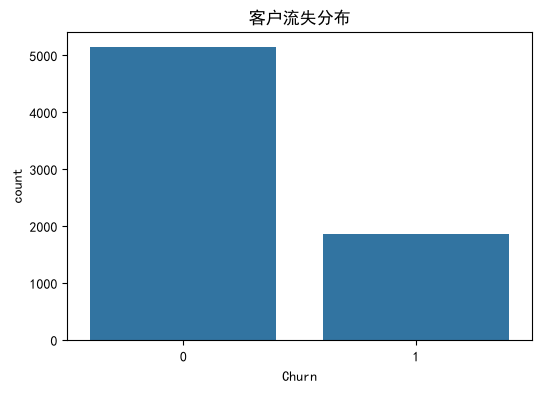

In [98]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn",data=df)
plt.title("客户流失分布")
plt.savefig("C:/Users/浩翔/archive/churn_dist.png", dpi=300, bbox_inches="tight")
plt.show()

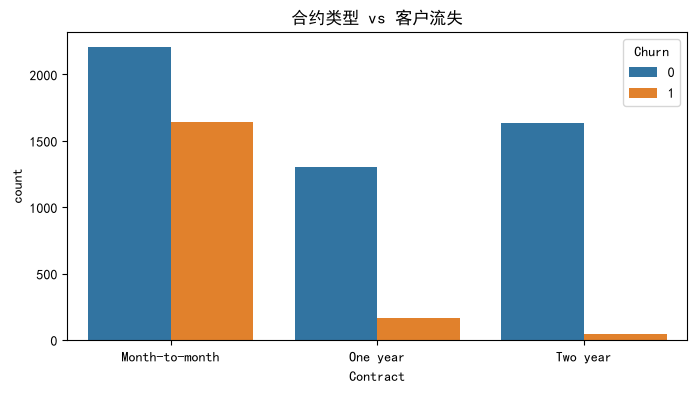

In [31]:
plt.figure(figsize=(8,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("合约类型 vs 客户流失")
plt.savefig("C:/Users/浩翔/archive/contract_churn.png", dpi=300, bbox_inches="tight")
plt.show()

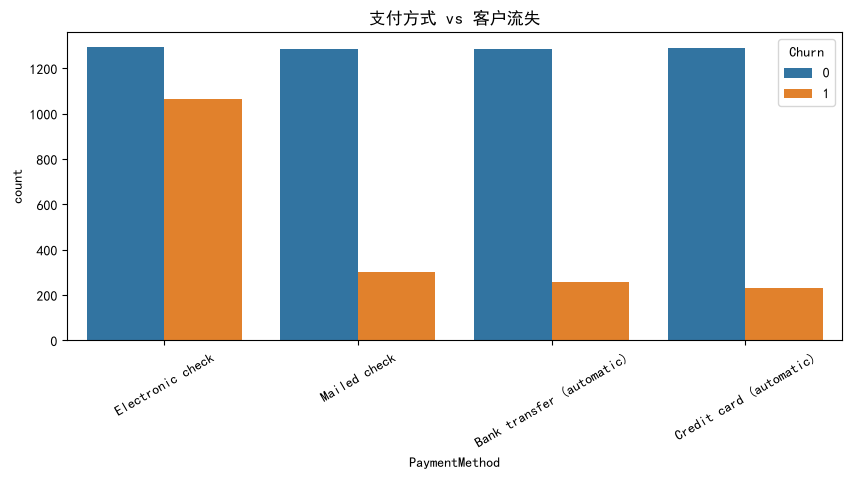

In [32]:
plt.figure(figsize=(10,4))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("支付方式 vs 客户流失")
plt.xticks(rotation=30)
plt.savefig("C:/Users/浩翔/archive/payment_churn.png", dpi=300, bbox_inches="tight")
plt.show()

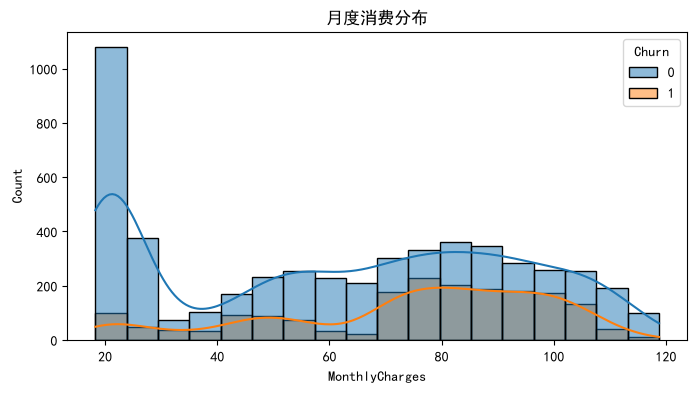

In [34]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True)
plt.title("月度消费分布")
plt.savefig("C:/Users/浩翔/archive/monthly_charge.png", dpi=300, bbox_inches="tight")
plt.show()

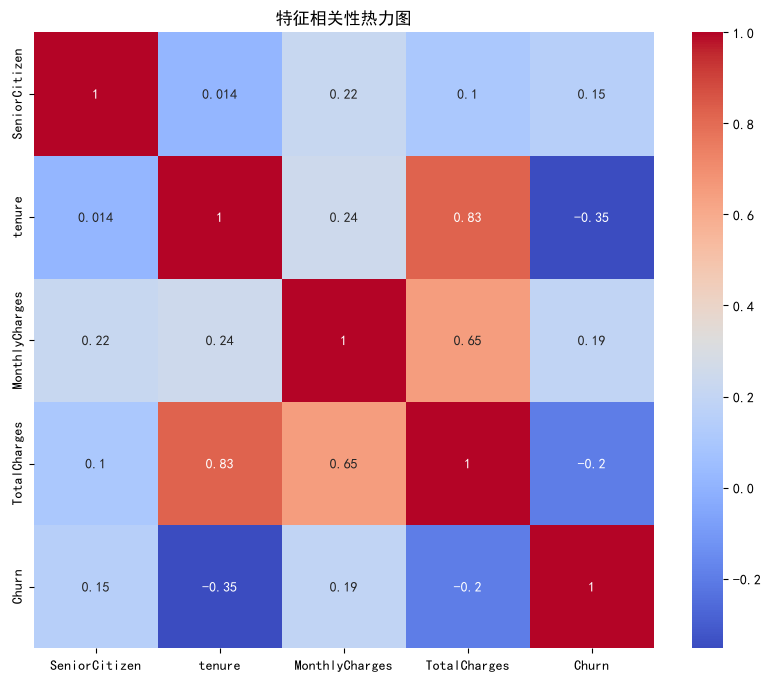

In [35]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("特征相关性热力图")
plt.savefig("C:/Users/浩翔/archive/corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [64]:
X = df.iloc[:,0:19]
y = df["Churn"]

In [65]:
print(X)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No          Yes   
1      

In [66]:
print(df.shape)            # (行数, 列数)
print(df.columns.tolist()) # 所有列名


(7010, 20)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [67]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_features = [col for col in X.columns if col not in num_features]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features)
    ],
    remainder="passthrough"
)


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [69]:
lr_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("lr", LogisticRegression(max_iter=1000))
])

In [70]:
lr_pipe.fit(X_train, y_train)

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2881: illegal multibyte sequence

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2881: illegal multibyte sequence

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                         

In [71]:
y_pred_lr = lr_pipe.predict(X_test)
y_pred_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

In [72]:
print("="*20)
print("逻辑回归模型评估")
print(classification_report(y_test, y_pred_lr))
print("AUC =", roc_auc_score(y_test, y_pred_prob_lr))
print("混淆矩阵：")
print(confusion_matrix(y_test, y_pred_lr))

逻辑回归模型评估
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1546
           1       0.69      0.56      0.62       557

    accuracy                           0.82      2103
   macro avg       0.77      0.73      0.75      2103
weighted avg       0.81      0.82      0.81      2103

AUC = 0.8511488499887355
混淆矩阵：
[[1404  142]
 [ 246  311]]


In [73]:
from sklearn.ensemble import RandomForestClassifier

In [74]:
rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

In [75]:
rf_pipe.fit(X_train, y_train)

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2881: illegal multibyte sequence

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2881: illegal multibyte sequence

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                         

In [76]:
y_pred_rf = rf_pipe.predict(X_test)
y_prob_rf = rf_pipe.predict_proba(X_test)[:,1]


In [77]:
print("===== 随机森林 =====")
print(f"准确率Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")
print(classification_report(y_test, y_pred_rf))

===== 随机森林 =====
准确率Accuracy: 0.797
AUC: 0.832
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1546
           1       0.67      0.47      0.55       557

    accuracy                           0.80      2103
   macro avg       0.75      0.69      0.71      2103
weighted avg       0.78      0.80      0.79      2103



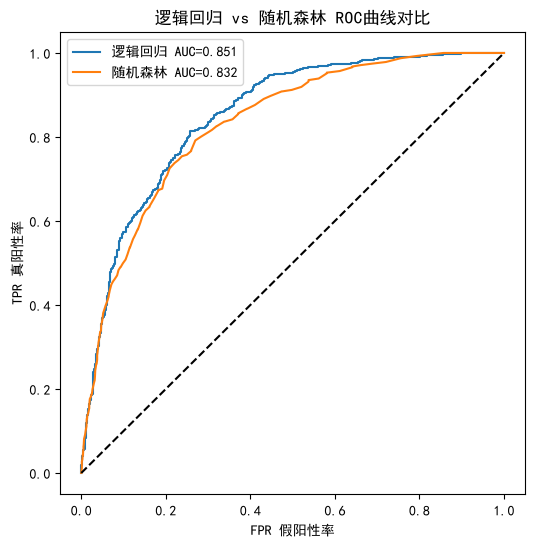

In [82]:
plt.figure(figsize=(6,6))
# 逻辑回归
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f"逻辑回归 AUC={roc_auc_score(y_test,y_pred_prob_lr):.3f}")
# 随机森林
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"随机森林 AUC={roc_auc_score(y_test,y_prob_rf):.3f}")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("FPR 假阳性率")
plt.ylabel("TPR 真阳性率")
plt.title("逻辑回归 vs 随机森林 ROC曲线对比")
plt.legend()
plt.savefig("C:/Users/浩翔/archive/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


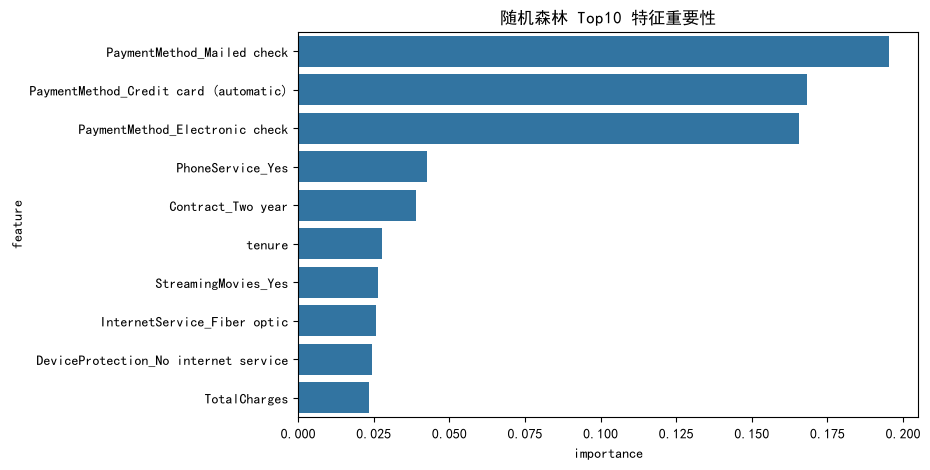

In [84]:
plt.figure(figsize=(8,5))
ohe = preprocessor.named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(cat_features).tolist()
all_feat_names = num_features + cat_names

rf_model = rf_pipe.named_steps["rf"]
imp_df = pd.DataFrame({
    "feature": all_feat_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).head(10)

sns.barplot(x="importance", y="feature", data=imp_df)
plt.title("随机森林 Top10 特征重要性")
plt.savefig("C:/Users/浩翔/archive/rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
